# Clasificación Binaria con PyTorch — Regresión Logística
### Dataset: Census Income KDD
**Laboratorio:** Inteligencia Artificial I  
**Objetivo:** Predecir si una persona gana más o menos de $50K al año,  
aplicando una Red Neuronal en PyTorch con Dataset, DataLoader y Checkpoints,  
basado en el modelo de regresión logística implementado en laboratorios anteriores.

---
## Contenido
1. Importaciones y configuración
2. Carga y análisis del dataset
3. Preprocesamiento con Pandas
4. Normalización y división de datos (80/20)
5. Función Sigmoide — conexión con el lab anterior
6. Clase Dataset personalizada + DataLoader
7. Red Neuronal para clasificación binaria
8. Entrenamiento con gráfica de costo y checkpoints
9. Evaluación del modelo
10. Guardar y cargar el modelo
11. Predicción sobre un nuevo ejemplo


## 1. Importaciones y Configuración

In [11]:
# ─── Librerías principales ───────────────────────────────────────────────────
import torch                              # Framework principal de Deep Learning
import torch.nn as nn                     # Módulo para construir redes neuronales
import numpy as np                        # Operaciones matemáticas con arrays
import pandas as pd                       # Carga y manipulación del dataset CSV
import matplotlib.pyplot as plt           # Visualización de gráficas

# ─── Scikit-learn: preprocesamiento y métricas ────────────────────────────────
from sklearn.model_selection import train_test_split   # División 80/20
from sklearn.preprocessing import StandardScaler       # Normalización (igual que featureNormalize del lab anterior)
from sklearn.preprocessing import LabelEncoder         # Codificación de variables categóricas
from sklearn.metrics import (
    accuracy_score,        # porcentaje de aciertos
    confusion_matrix,      # matriz de confusión: VP, VN, FP, FN
    classification_report  # precisión, recall y F1 por clase
)

# ─── Configuración del dispositivo ───────────────────────────────────────────
# Si hay GPU disponible la usamos para entrenar más rápido
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo disponible: {device}")

Dispositivo disponible: cpu


## 2. Carga y Análisis del Dataset
El dataset **Census Income KDD** contiene más de **199,000 registros** con **40+ variables**  
demográficas y laborales. La variable objetivo indica si el ingreso anual supera los $50K.

In [12]:
# ─── Carga del archivo .data ─────────────────────────────────────────────────
# El archivo no tiene encabezado, lo definimos manualmente
# Ajustá la ruta si tu archivo está en otra carpeta
nombres_columnas = [
    'age', 'class_of_worker', 'industry_code', 'occupation_code',
    'education', 'wage_per_hour', 'enrolled_in_edu', 'marital_status',
    'major_industry', 'major_occupation', 'race', 'hispanic_origin',
    'sex', 'member_labor_union', 'reason_unemployment', 'full_part_time',
    'capital_gains', 'capital_losses', 'dividends', 'tax_filer_status',
    'region_prev_residence', 'state_prev_residence', 'detailed_household',
    'detailed_household_summary', 'instance_weight', 'migration_msa',
    'migration_reg', 'migration_within_reg', 'live_1_year_ago',
    'migration_sunbelt', 'num_persons_worked', 'family_members_18',
    'country_father', 'country_mother', 'country_self', 'citizenship',
    'own_business', 'veterans_questionnaire', 'veterans_benefit', 'weeks_worked',
    'year', 'income'     # columna 41 = variable objetivo
]

df = pd.read_csv(
    'census-income[1].data',   # nombre exacto del archivo en tu carpeta
    header=None,
    names=nombres_columnas
)

print(f"Dimensiones del dataset: {df.shape}")
print(f"  → {df.shape[0]:,} registros y {df.shape[1]} columnas")

Dimensiones del dataset: (199523, 42)
  → 199,523 registros y 42 columnas


In [13]:
# ─── Vista previa de los primeros registros ──────────────────────────────────
df.head()

,age,class_of_worker,industry_code,occupation_code,education,wage_per_hour,enrolled_in_edu,marital_status,major_industry,major_occupation,...,country_father,country_mother,country_self,citizenship,own_business,veterans_questionnaire,veterans_benefit,weeks_worked,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [14]:
# ─── Información general del dataset ─────────────────────────────────────────
# Nos muestra el tipo de dato de cada columna y cuántos valores no nulos hay
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   age                         199523 non-null  int64  
 1   class_of_worker             199523 non-null  str    
 2   industry_code               199523 non-null  int64  
 3   occupation_code             199523 non-null  int64  
 4   education                   199523 non-null  str    
 5   wage_per_hour               199523 non-null  int64  
 6   enrolled_in_edu             199523 non-null  str    
 7   marital_status              199523 non-null  str    
 8   major_industry              199523 non-null  str    
 9   major_occupation            199523 non-null  str    
 10  race                        199523 non-null  str    
 11  hispanic_origin             199523 non-null  str    
 12  sex                         199523 non-null  str    
 13  member_labor_union       

In [15]:
# ─── Distribución de la variable objetivo ────────────────────────────────────
# Verificamos el balance entre clases: cuántas personas ganan >50K y cuántas <=50K
print("Distribución de la variable objetivo 'income':")
print(df['income'].value_counts())
print()
print("Porcentaje por clase:")
print(df['income'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Distribución de la variable objetivo 'income':
income
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

Porcentaje por clase:
income
- 50000.    93.79%
50000+.      6.21%
Name: proportion, dtype: str


In [16]:
# ─── Verificar valores nulos ──────────────────────────────────────────────────
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "No hay valores nulos ✔")

Valores nulos por columna:
No hay valores nulos ✔


## 3. Preprocesamiento con Pandas
Aplicamos `LabelEncoder` para convertir variables categóricas a números,  
igual que en el laboratorio anterior pero con Pandas.

In [17]:
# ─── Separar características (X) y variable objetivo (y) ─────────────────────
# X: todas las columnas excepto 'income'
# y: la columna 'income' (lo que queremos predecir)
X = df.drop(columns=['income'])   # DataFrame con 41 columnas de características
y = df['income']                   # Serie con la clase: <=50K o >50K

print(f"Variables de entrada X: {X.shape}")
print(f"Variable objetivo y:    {y.shape}")

Variables de entrada X: (199523, 41)
Variable objetivo y:    (199523,)


In [18]:
# ─── Codificación de variables categóricas con LabelEncoder ──────────────────
# Las columnas de texto (ej: 'sex': 'Male'/'Female') deben convertirse a números
# LabelEncoder asigna un número entero a cada categoría única
# Ej: 'Male' → 0, 'Female' → 1

label_encoder = LabelEncoder()

for columna in X.columns:
    # Verificamos si la columna es de tipo texto (object)
    if X[columna].dtype == 'object':
        X[columna] = label_encoder.fit_transform(X[columna].astype(str))

# Codificamos también la variable objetivo
# <=50K → 0 (no supera los $50K)
# >50K  → 1 (supera los $50K)
y_encoded = label_encoder.fit_transform(y.astype(str))

print("Codificación de clases:")
for i, clase in enumerate(label_encoder.classes_):
    print(f"  '{clase}' → {i}")

print(f"\nValores únicos en y: {np.unique(y_encoded)}")

Codificación de clases:
  ' - 50000.' → 0
  ' 50000+.' → 1

Valores únicos en y: [0 1]


In [19]:
# ─── Forzar conversión de columnas que quedaron como texto ───────────────────
# Algunas columnas mixtas (números + strings como ' Not in universe')
# no fueron capturadas por el LabelEncoder anterior porque no eran tipo 'object'
# Las detectamos y las codificamos ahora

label_encoder2 = LabelEncoder()

for columna in X.columns:
    # Intentamos convertir a float, si falla la codificamos
    try:
        X[columna] = pd.to_numeric(X[columna], errors='raise')
    except (ValueError, TypeError):
        X[columna] = label_encoder2.fit_transform(X[columna].astype(str))

# ─── Convertir a arrays numpy ─────────────────────────────────────────────────
X_array = X.values.astype(np.float64)   # ahora sí todas numéricas
y_array = y_encoded.astype(np.float64)

print(f"Shape X: {X_array.shape}")
print(f"Shape y: {y_array.shape}")

Shape X: (199523, 41)
Shape y: (199523,)


## 4. Normalización y División de Datos (80/20)
Aplicamos la misma lógica de `featureNormalize` del laboratorio anterior,  
pero usando `StandardScaler` de sklearn. El 80% se usa para entrenar y el 20% para probar.

In [20]:
# ─── División 80% entrenamiento / 20% prueba ─────────────────────────────────
# Los datos de prueba NO participan en el entrenamiento (requisito del laboratorio)
# random_state=42 garantiza que el split sea siempre el mismo
X_train, X_test, y_train, y_test = train_test_split(
    X_array,
    y_array,
    test_size=0.2,       # 20% para prueba
    random_state=42,     # semilla para reproducibilidad
    stratify=y_array     # mantiene la proporción de clases en cada split
)

print(f"Entrenamiento: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(X_array)*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]:,} muestras ({X_test.shape[0]/len(X_array)*100:.0f}%)")

Entrenamiento: 159,618 muestras (80%)
Prueba:        39,905 muestras (20%)


In [21]:
# ─── Normalización de características ────────────────────────────────────────
# Equivalente a featureNormalize() del lab anterior: media=0, desviación=1
# IMPORTANTE: hacemos fit() solo en train, transform() en ambos
# Si hiciéramos fit() en test también, estaríamos usando info del test en el train (trampa)

scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)   # fit + transform en entrenamiento
X_test_norm  = scaler.transform(X_test)        # solo transform en prueba

print(f"Media de X_train normalizado: {X_train_norm.mean(axis=0).round(3)}")
print(f"Std  de X_train normalizado:  {X_train_norm.std(axis=0).round(3)}")

Media de X_train normalizado: [ 0. -0.  0.  0. -0. -0. -0. -0.  0. -0. -0.  0.  0. -0.  0. -0. -0.  0.
  0.  0.  0. -0.  0.  0. -0. -0.  0. -0.  0. -0. -0.  0. -0. -0.  0. -0.
  0.  0.  0. -0.  0.]
Std  de X_train normalizado:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Función Sigmoide — Conexión con el Lab Anterior
En el laboratorio anterior implementamos la sigmoide manualmente.  
PyTorch la tiene incorporada como `torch.sigmoid()` y también como `nn.Sigmoid()`.  
Aquí mostramos ambas para ver la equivalencia.

In [22]:
# ─── Sigmoide manual (igual que en el lab anterior) ──────────────────────────
def sigmoid_manual(z):
    """
    Función sigmoide implementada con numpy
    g(z) = 1 / (1 + e^(-z))
    Convierte cualquier número real a un valor entre 0 y 1
    → Valores cercanos a 1: alta probabilidad de clase positiva (>50K)
    → Valores cercanos a 0: alta probabilidad de clase negativa (<=50K)
    """
    return 1 / (1 + np.exp(-z))

# ─── Comparación: sigmoide manual vs PyTorch ─────────────────────────────────
z_valores = np.array([-3, -1, 0, 1, 3])

print("Comparación sigmoide manual vs PyTorch:")
print(f"{'z':>6} | {'Manual':>10} | {'PyTorch':>10}")
print("-" * 32)
for z in z_valores:
    manual  = sigmoid_manual(z)
    pytorch = torch.sigmoid(torch.tensor(z, dtype=torch.float32)).item()
    print(f"{z:>6} | {manual:>10.6f} | {pytorch:>10.6f}")

print("\n→ Resultados idénticos ✔")

Comparación sigmoide manual vs PyTorch:
     z |     Manual |    PyTorch
--------------------------------
    -3 |   0.047426 |   0.047426
    -1 |   0.268941 |   0.268941
     0 |   0.500000 |   0.500000
     1 |   0.731059 |   0.731059
     3 |   0.952574 |   0.952574

→ Resultados idénticos ✔


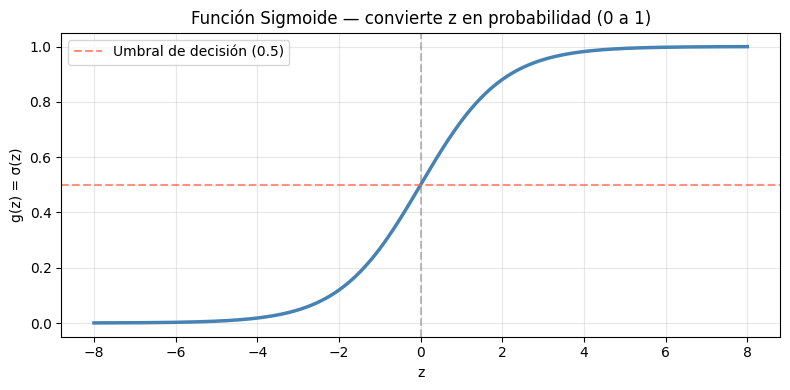

In [23]:
# ─── Gráfica de la función sigmoide ──────────────────────────────────────────
z = np.linspace(-8, 8, 300)
g = sigmoid_manual(z)

plt.figure(figsize=(8, 4))
plt.plot(z, g, 'steelblue', lw=2.5)
plt.axhline(0.5, color='tomato', linestyle='--', alpha=0.7, label='Umbral de decisión (0.5)')
plt.axvline(0,   color='gray',   linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('g(z) = σ(z)')
plt.title('Función Sigmoide — convierte z en probabilidad (0 a 1)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Clase Dataset Personalizada + DataLoader
Aplicamos el patrón del cuadernillo 03: creamos `CensusDataset` para gestionar  
el dataset Census Income, y usamos `DataLoader` para iterar en mini-batches.

In [24]:
# ─── Clase Dataset para Census Income ────────────────────────────────────────
class CensusDataset(torch.utils.data.Dataset):

    def __init__(self, X, y):
        """
        Constructor: convierte arrays numpy a tensores de PyTorch
        X: matriz de características normalizadas → float32
        y: vector de etiquetas binarias (0 o 1)  → float32
        """
        # float32 porque PyTorch trabaja con 32 bits por defecto
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.y = torch.tensor(y, dtype=torch.float32).to(device)

    def __len__(self):
        """Retorna el total de muestras — el DataLoader usa esto para los batches"""
        return len(self.X)

    def __getitem__(self, idx):
        """Retorna la muestra en la posición idx — el DataLoader llama a esto"""
        return self.X[idx], self.y[idx]


# ─── Instanciar datasets ──────────────────────────────────────────────────────
dataset_train = CensusDataset(X_train_norm, y_train)
dataset_test  = CensusDataset(X_test_norm,  y_test)

print(f"Dataset entrenamiento: {len(dataset_train):,} muestras")
print(f"Dataset prueba:        {len(dataset_test):,} muestras")

# Verificamos que una muestra tiene la forma correcta
x_muestra, y_muestra = dataset_train[0]
print(f"\nShape de una muestra X: {x_muestra.shape}")   # (41,) → 41 características
print(f"Etiqueta (clase):        {y_muestra.item()}")   # 0 o 1

Dataset entrenamiento: 159,618 muestras
Dataset prueba:        39,905 muestras

Shape de una muestra X: torch.Size([41])
Etiqueta (clase):        0.0


In [25]:
# ─── DataLoader: gestiona los mini-batches ────────────────────────────────────
# En lugar de entrenar con los 159,000 ejemplos a la vez (batch gradient descent),
# usamos mini-batches de 512 ejemplos para converger más rápido
BATCH_SIZE = 512

dataloader_train = torch.utils.data.DataLoader(
    dataset_train,
    batch_size=BATCH_SIZE,
    shuffle=True    # mezclar en cada epoch → evita que el modelo aprenda el orden
)

dataloader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=BATCH_SIZE,
    shuffle=False   # no mezclar en evaluación
)

# Verificamos el shape de un batch
x_batch, y_batch = next(iter(dataloader_train))
print(f"Shape de un batch X: {x_batch.shape}")  # (512, 41) → 512 registros, 41 características
print(f"Shape de un batch y: {y_batch.shape}")  # (512,)    → 512 etiquetas

Shape de un batch X: torch.Size([512, 41])
Shape de un batch y: torch.Size([512])


## 7. Red Neuronal para Clasificación Binaria
En el lab anterior usamos la sigmoide + gradiente descendente manual.  
Ahora definimos una red neuronal con `torch.nn.Module` (cuadernillo 02)  
que internamente aplica la sigmoide en la capa final para clasificación binaria.

In [26]:
# ─── Red Neuronal para Clasificación Binaria ─────────────────────────────────
class RedClasificacion(nn.Module):

    def __init__(self, n_entradas, n_ocultas_1=128, n_ocultas_2=64, n_ocultas_3=32):
        """
        n_entradas: número de características de entrada (41 columnas del Census)
        n_ocultas_1/2/3: neuronas en cada capa oculta
        """
        # Llamamos al constructor de la clase madre (obligatorio en PyTorch)
        super(RedClasificacion, self).__init__()

        # ── Capas de la red ──────────────────────────────────────────────────
        self.capa1 = nn.Linear(n_entradas, n_ocultas_1)   # entrada → capa 1
        self.capa2 = nn.Linear(n_ocultas_1, n_ocultas_2)  # capa 1  → capa 2
        self.capa3 = nn.Linear(n_ocultas_2, n_ocultas_3)  # capa 2  → capa 3
        self.salida = nn.Linear(n_ocultas_3, 1)            # capa 3  → 1 neurona de salida

        # ── Activaciones y regularización ────────────────────────────────────
        self.relu    = nn.ReLU()      # función de activación entre capas ocultas
        self.sigmoid = nn.Sigmoid()   # función sigmoide en la capa final
                                      # convierte el output a probabilidad (0-1)
                                      # igual que g(z) = 1/(1+e^-z) del lab anterior
        self.dropout = nn.Dropout(p=0.3)  # apaga 30% de neuronas aleatoriamente
                                           # para evitar que el modelo memorice los datos

    def forward(self, x):
        """
        Define el flujo de los datos por la red (propagación hacia adelante)
        Equivalente a: h = sigmoid(X · theta) del lab anterior
        """
        # Capas ocultas: transformación lineal → ReLU → Dropout
        x = self.dropout(self.relu(self.capa1(x)))
        x = self.dropout(self.relu(self.capa2(x)))
        x = self.dropout(self.relu(self.capa3(x)))

        # Capa de salida: transformación lineal → Sigmoide
        # La sigmoide da la probabilidad de que sea clase 1 (>50K)
        x = self.sigmoid(self.salida(x))

        # squeeze(-1) elimina la dimensión extra: (batch, 1) → (batch,)
        return x.squeeze(-1)


# ─── Instanciar el modelo ─────────────────────────────────────────────────────
N_FEATURES = X_train_norm.shape[1]   # 41 características del Census
modelo = RedClasificacion(n_entradas=N_FEATURES).to(device)

print(modelo)
print(f"\nNúmero de parámetros entrenables: {sum(p.numel() for p in modelo.parameters()):,}")

RedClasificacion(
  (capa1): Linear(in_features=41, out_features=128, bias=True)
  (capa2): Linear(in_features=128, out_features=64, bias=True)
  (capa3): Linear(in_features=64, out_features=32, bias=True)
  (salida): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.3, inplace=False)
)

Número de parámetros entrenables: 15,745


## 8. Entrenamiento con Gráfica de Costo y Checkpoints
Usamos `BCELoss` (Binary Cross Entropy), que es exactamente la misma función  
de costo J(θ) implementada manualmente en el lab anterior.

In [27]:
# ─── Función de costo: Binary Cross Entropy (BCE) ────────────────────────────
# Es la MISMA función calcularCosto() del lab anterior:
# J(θ) = (-1/m) * Σ [y*log(h) + (1-y)*log(1-h)]
# PyTorch la tiene implementada de forma optimizada y numéricamente estable
criterio = nn.BCELoss()

# ─── Optimizador: Adam ────────────────────────────────────────────────────────
# Más eficiente que el gradiente descendente manual del lab anterior
# Ajusta automáticamente la tasa de aprendizaje para cada parámetro
optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

# ─── Scheduler: reduce lr si no mejora ───────────────────────────────────────
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', patience=5, factor=0.5
)

EPOCHS = 50                                    # épocas de entrenamiento
CHECKPOINT_PATH = './clasificacion_mejor_modelo.pt'

print(f"Función de costo: Binary Cross Entropy (= calcularCosto del lab anterior)")
print(f"Optimizador: Adam (lr=0.001)")
print(f"Épocas: {EPOCHS}")

Función de costo: Binary Cross Entropy (= calcularCosto del lab anterior)
Optimizador: Adam (lr=0.001)
Épocas: 50


In [28]:
# ─── Bucle de entrenamiento con checkpoints ───────────────────────────────────
historico_costo_train = []   # evolución del costo en entrenamiento (para la gráfica)
historico_costo_test  = []   # evolución del costo en validación
historico_acc_test    = []   # accuracy en test por época
mejor_costo           = float('inf')

for epoca in range(1, EPOCHS + 1):

    # ── FASE DE ENTRENAMIENTO ────────────────────────────────────────────────
    modelo.train()   # activa Dropout (modo entrenamiento)
    costos_train = []

    for x_batch, y_batch in dataloader_train:
        # 1. Forward: calculamos las probabilidades predichas (h = sigmoid(z))
        y_pred = modelo(x_batch)

        # 2. Calculamos el costo (equivalente a calcularCosto del lab anterior)
        costo = criterio(y_pred, y_batch)
        costos_train.append(costo.item())

        # 3. Reseteamos gradientes (evita acumulación de épocas anteriores)
        optimizador.zero_grad()

        # 4. Backpropagation: PyTorch calcula ∂J/∂θ automáticamente
        costo.backward()

        # 5. El optimizador actualiza θ (equivalente a: θ = θ - α * gradiente)
        optimizador.step()

    # ── FASE DE EVALUACIÓN ───────────────────────────────────────────────────
    modelo.eval()    # desactiva Dropout (modo evaluación)
    costos_test = []
    predicciones, etiquetas_reales = [], []

    with torch.no_grad():   # no necesitamos gradientes al evaluar
        for x_batch, y_batch in dataloader_test:
            y_pred = modelo(x_batch)
            costo  = criterio(y_pred, y_batch)
            costos_test.append(costo.item())

            # Convertir probabilidades a clases: ≥0.5 → 1, <0.5 → 0
            # (igual que predict() del lab anterior: prob >= 0.5)
            clases_pred = (y_pred >= 0.5).float()
            predicciones.extend(clases_pred.cpu().numpy())
            etiquetas_reales.extend(y_batch.cpu().numpy())

    # ── Métricas de la época ─────────────────────────────────────────────────
    costo_train_ep = np.mean(costos_train)
    costo_test_ep  = np.mean(costos_test)
    acc_test_ep    = accuracy_score(etiquetas_reales, predicciones)

    historico_costo_train.append(costo_train_ep)
    historico_costo_test.append(costo_test_ep)
    historico_acc_test.append(acc_test_ep)

    scheduler.step(costo_test_ep)

    # ── CHECKPOINT: guardar si es el mejor modelo hasta ahora ────────────────
    if costo_test_ep < mejor_costo:
        mejor_costo = costo_test_ep
        torch.save(modelo.state_dict(), CHECKPOINT_PATH)
        print(f"  ✔ Época {epoca:2d} | Nuevo mejor modelo (val_loss={costo_test_ep:.5f} | acc={acc_test_ep:.4f})")

    if not epoca % 5:
        print(f"  Época {epoca:2d}/{EPOCHS} | Train Loss: {costo_train_ep:.5f} | Val Loss: {costo_test_ep:.5f} | Acc: {acc_test_ep:.4f}")

# Cargamos el mejor modelo guardado
modelo.load_state_dict(torch.load(CHECKPOINT_PATH, weights_only=True))
print(f"\n✔ Entrenamiento finalizado. Mejor val_loss: {mejor_costo:.5f}")

  ✔ Época  1 | Nuevo mejor modelo (val_loss=0.13523 | acc=0.9484)
  ✔ Época  2 | Nuevo mejor modelo (val_loss=0.13246 | acc=0.9495)
  ✔ Época  3 | Nuevo mejor modelo (val_loss=0.13159 | acc=0.9497)
  ✔ Época  4 | Nuevo mejor modelo (val_loss=0.13004 | acc=0.9508)
  ✔ Época  5 | Nuevo mejor modelo (val_loss=0.12879 | acc=0.9507)
  Época  5/50 | Train Loss: 0.13633 | Val Loss: 0.12879 | Acc: 0.9507
  ✔ Época  6 | Nuevo mejor modelo (val_loss=0.12865 | acc=0.9503)
  ✔ Época  7 | Nuevo mejor modelo (val_loss=0.12758 | acc=0.9509)
  ✔ Época  9 | Nuevo mejor modelo (val_loss=0.12737 | acc=0.9507)
  ✔ Época 10 | Nuevo mejor modelo (val_loss=0.12690 | acc=0.9512)
  Época 10/50 | Train Loss: 0.13120 | Val Loss: 0.12690 | Acc: 0.9512
  ✔ Época 11 | Nuevo mejor modelo (val_loss=0.12677 | acc=0.9510)
  ✔ Época 12 | Nuevo mejor modelo (val_loss=0.12609 | acc=0.9514)
  ✔ Época 14 | Nuevo mejor modelo (val_loss=0.12559 | acc=0.9514)
  Época 15/50 | Train Loss: 0.12897 | Val Loss: 0.12577 | Acc: 0.951

## 9. Evaluación del Modelo

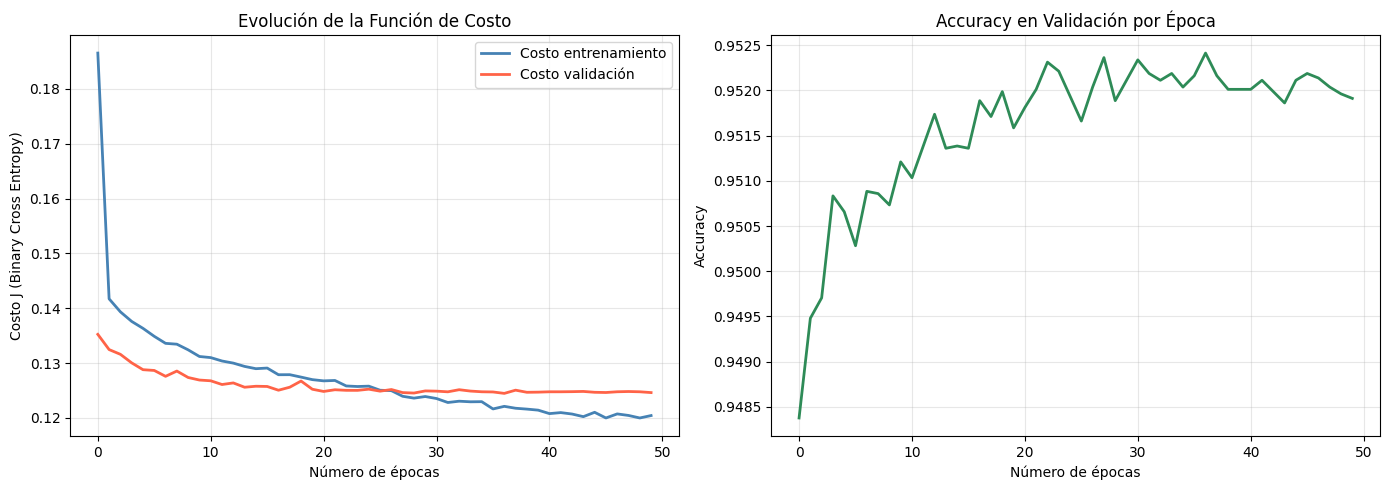

In [29]:
# ─── Gráfica de costo (convergencia) ─────────────────────────────────────────
# Equivalente a la gráfica pyplot.plot(cost_history) del lab anterior
# Si ambas curvas bajan juntas → el modelo aprende correctamente
# Si train baja pero test sube → overfitting (memorización)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de costo
ax1.plot(historico_costo_train, label='Costo entrenamiento', color='steelblue', lw=2)
ax1.plot(historico_costo_test,  label='Costo validación',    color='tomato',    lw=2)
ax1.set_xlabel('Número de épocas')
ax1.set_ylabel('Costo J (Binary Cross Entropy)')
ax1.set_title('Evolución de la Función de Costo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfica de accuracy
ax2.plot(historico_acc_test, color='seagreen', lw=2)
ax2.set_xlabel('Número de épocas')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy en Validación por Época')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# ─── Métricas finales del modelo ─────────────────────────────────────────────
modelo.eval()
todas_predicciones = []
todas_etiquetas    = []

with torch.no_grad():
    for x_batch, y_batch in dataloader_test:
        y_pred = modelo(x_batch)
        clases_pred = (y_pred >= 0.5).float()
        todas_predicciones.extend(clases_pred.cpu().numpy())
        todas_etiquetas.extend(y_batch.cpu().numpy())

# ── Accuracy ─────────────────────────────────────────────────────────────────
acc = accuracy_score(todas_etiquetas, todas_predicciones)
print(f"Precisión del modelo (Accuracy): {acc:.4f}  ({acc*100:.2f}%)")
print(f"  → Por cada 100 personas, el modelo acierta en {acc*100:.0f}")

# ── Reporte completo ─────────────────────────────────────────────────────────
print("\nReporte de clasificación:")
print(classification_report(
    todas_etiquetas,
    todas_predicciones,
    target_names=['<=50K (clase 0)', '>50K (clase 1)']
))

Precisión del modelo (Accuracy): 0.9524  (95.24%)
  → Por cada 100 personas, el modelo acierta en 95

Reporte de clasificación:
                 precision    recall  f1-score   support

<=50K (clase 0)       0.96      0.99      0.98     37429
 >50K (clase 1)       0.71      0.39      0.50      2476

       accuracy                           0.95     39905
      macro avg       0.84      0.69      0.74     39905
   weighted avg       0.95      0.95      0.95     39905



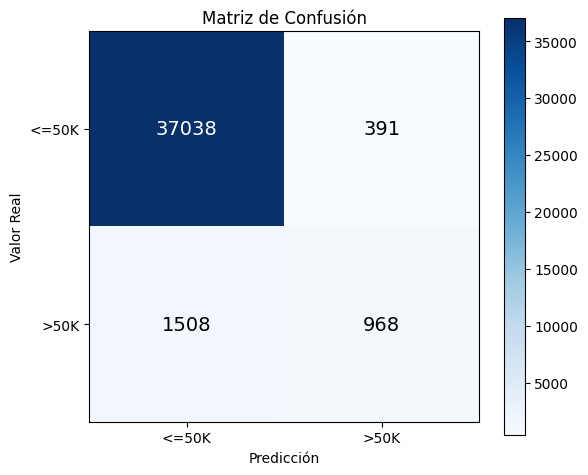

In [31]:
# ─── Matriz de confusión ──────────────────────────────────────────────────────
# Muestra cuántas predicciones fueron correctas e incorrectas por clase:
# - Verdaderos Positivos (VP): predijo >50K y era >50K ✔
# - Verdaderos Negativos (VN): predijo <=50K y era <=50K ✔
# - Falsos Positivos (FP):     predijo >50K pero era <=50K ✗
# - Falsos Negativos (FN):     predijo <=50K pero era >50K ✗

cm = confusion_matrix(todas_etiquetas, todas_predicciones)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

clases = ['<=50K', '>50K']
ax.set_xticks([0, 1]); ax.set_xticklabels(clases)
ax.set_yticks([0, 1]); ax.set_yticklabels(clases)
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
ax.set_title('Matriz de Confusión')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

plt.tight_layout()
plt.show()

## 10. Guardar y Cargar el Modelo
Aplicamos lo del cuadernillo 04: guardamos el `state_dict` y verificamos que el modelo cargado funciona igual.

In [32]:
# ─── Guardar el state_dict (método recomendado del cuadernillo 04) ───────────
# state_dict: diccionario con todos los pesos y bias de la red
PATH_FINAL = './clasificacion_modelo_final.pt'
torch.save(modelo.state_dict(), PATH_FINAL)
print(f"Modelo guardado en: {PATH_FINAL}")

# ─── Cargar el modelo ─────────────────────────────────────────────────────────
# Necesitamos instanciar la arquitectura primero, luego cargar los pesos
modelo_cargado = RedClasificacion(n_entradas=N_FEATURES).to(device)
modelo_cargado.load_state_dict(torch.load(PATH_FINAL, weights_only=True))
modelo_cargado.eval()
print("Modelo cargado correctamente ✔")

Modelo guardado en: ./clasificacion_modelo_final.pt
Modelo cargado correctamente ✔


In [33]:
# ─── Verificar que el modelo cargado da las mismas predicciones ──────────────
x_verificacion = dataset_test[0][0].unsqueeze(0)   # primera muestra del test

with torch.no_grad():
    prob_original = modelo(x_verificacion).item()
    prob_cargado  = modelo_cargado(x_verificacion).item()

print(f"Probabilidad (modelo original): {prob_original:.6f}")
print(f"Probabilidad (modelo cargado):  {prob_cargado:.6f}")
print(f"Predicción: {'> 50K ✔' if prob_original >= 0.5 else '<= 50K ✔'}")

Probabilidad (modelo original): 0.000000
Probabilidad (modelo cargado):  0.000000
Predicción: <= 50K ✔


## 11. Predicción sobre un Nuevo Ejemplo
Demostramos cómo usar el modelo para predecir si una persona específica  
gana más o menos de $50K al año.

In [34]:
# ─── Predicción de una persona nueva ─────────────────────────────────────────
# Ingresamos los valores de las 41 características en el mismo orden del dataset
# (todos los valores ya deben ser numéricos — las categorías codificadas)

persona_nueva = np.array([[
    45,   # age: 45 años
    4,    # class_of_worker: empleado privado (codificado)
    7,    # industry_code
    3,    # occupation_code: gerencial
    12,   # education: universidad completa (codificado)
    0,    # wage_per_hour
    0,    # enrolled_in_edu
    1,    # marital_status: casado
    3,    # major_industry
    2,    # major_occupation
    0,    # race: blanco (codificado)
    0,    # hispanic_origin
    1,    # sex: masculino (codificado)
    0,    # member_labor_union
    0,    # reason_unemployment
    1,    # full_part_time: tiempo completo
    5000, # capital_gains
    0,    # capital_losses
    200,  # dividends
    2,    # tax_filer_status
    0,    # region_prev_residence
    0,    # state_prev_residence
    0,    # detailed_household
    1,    # detailed_household_summary
    1500, # instance_weight
    0,    # migration_msa
    0,    # migration_reg
    0,    # migration_within_reg
    1,    # live_1_year_ago
    0,    # migration_sunbelt
    2,    # num_persons_worked
    0,    # family_members_18
    0,    # country_father
    0,    # country_mother
    0,    # country_self
    1,    # citizenship
    0,    # own_business
    0,    # veterans_questionnaire
    2,    # veterans_benefit
    52,   # weeks_worked: trabajó 52 semanas
    94,   # year
]])

# ─── Normalizar con el mismo scaler del entrenamiento ─────────────────────────
# MUY IMPORTANTE: usamos el scaler que se entrenó con los datos de train
persona_norm   = scaler.transform(persona_nueva)
persona_tensor = torch.tensor(persona_norm, dtype=torch.float32).to(device)

# ─── Predicción ──────────────────────────────────────────────────────────────
modelo_cargado.eval()
with torch.no_grad():
    probabilidad = modelo_cargado(persona_tensor).item()
    clase_pred   = 1 if probabilidad >= 0.5 else 0

print("=" * 50)
print("      PREDICCIÓN DE INGRESO ANUAL")
print("=" * 50)
print(f"  Edad:             45 años")
print(f"  Educación:        Universitaria")
print(f"  Estado civil:     Casado")
print(f"  Semanas trabajadas: 52")
print(f"  Ganancias de capital: $5,000")
print("-" * 50)
print(f"  Probabilidad de ganar >$50K: {probabilidad:.4f} ({probabilidad*100:.1f}%)")
print(f"  Predicción: {'> $50K al año ✔' if clase_pred == 1 else '<= $50K al año'}")
print("=" * 50)

      PREDICCIÓN DE INGRESO ANUAL
  Edad:             45 años
  Educación:        Universitaria
  Estado civil:     Casado
  Semanas trabajadas: 52
  Ganancias de capital: $5,000
--------------------------------------------------
  Probabilidad de ganar >$50K: 0.2177 (21.8%)
  Predicción: <= $50K al año


## Resumen

Aplicamos las herramientas de los cuadernillos 02, 03 y 04 al modelo de clasificación  
binaria del laboratorio anterior (regresión logística con Census Income KDD):

| Concepto lab anterior | Equivalente en PyTorch | Cuadernillo |
|---|---|---|
| `sigmoid()` manual con numpy | `nn.Sigmoid()` / `torch.sigmoid()` | 02 |
| `calcularCosto()` manual | `nn.BCELoss()` (Binary Cross Entropy) | 02 |
| `descensoGradiente()` manual | `torch.optim.Adam` | 02 |
| Arrays numpy directos | `CensusDataset` (`torch.utils.data.Dataset`) | 03 |
| Iterar datos manualmente | `DataLoader` con mini-batches de 512 | 03 |
| Sin guardado de modelo | `torch.save` + checkpoint del mejor modelo | 04 |
| `predict()` con numpy | `(y_pred >= 0.5).float()` con tensores | 02 |

**Mejoras respecto al laboratorio anterior:**
- Reemplazamos el gradiente descendente manual por `Adam` (más rápido y eficiente)
- La red neuronal aprende representaciones más complejas que la regresión logística simple
- Dropout previene el overfitting automáticamente
- Guardamos el mejor modelo durante el entrenamiento con checkpoints
